   age   bmi  glucose  blood_pressure  insulin  diabetes
0   42  25.8      195             101      178         1
1   53  31.7      162             138      186         1
2   78  31.0      111             129      185         1
3   27  35.3      137              89      258         1
4   78  16.9      169             111       44         0

Class Distribution:
 diabetes
1    500
0    500
Name: count, dtype: int64
----- Logistic Regression -----
Accuracy : 0.45
Precision: 0.4479166666666667
Recall   : 0.43
F1 Score : 0.4387755102040816



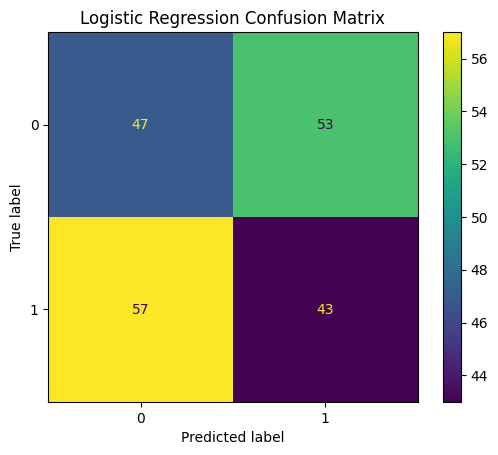

----- Random Forest -----
Accuracy : 0.495
Precision: 0.49473684210526314
Recall   : 0.47
F1 Score : 0.48205128205128206



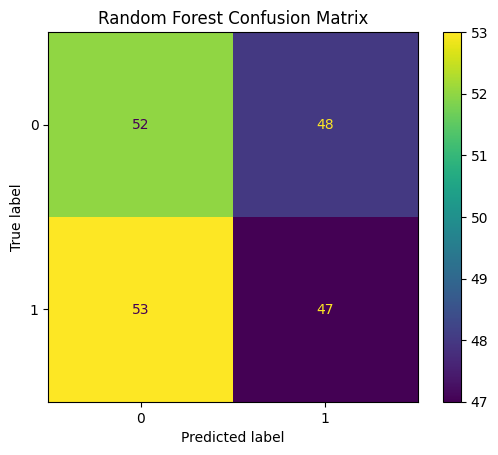

----- SVM -----
Accuracy : 0.455
Precision: 0.45054945054945056
Recall   : 0.41
F1 Score : 0.4293193717277487



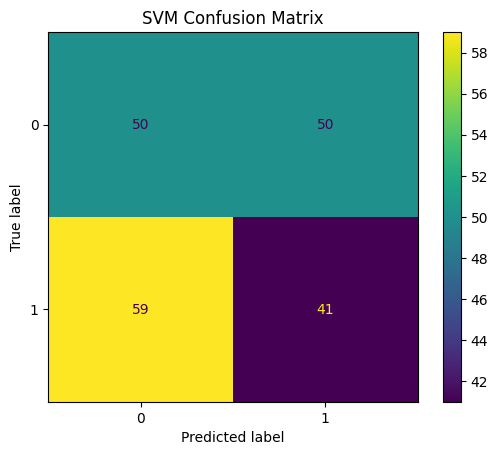

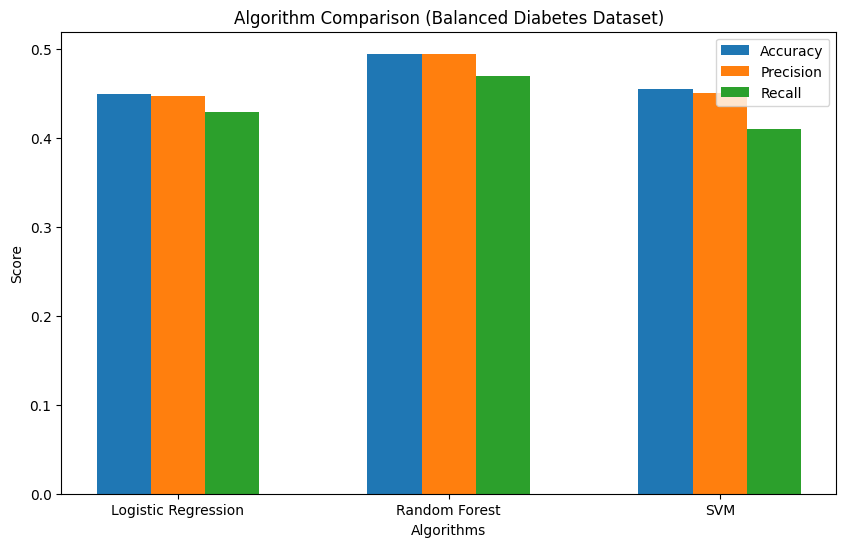

Best Algorithm based on Accuracy: Random Forest


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# -------------------------------
# Load dataset (CHANGE PATH HERE)
# -------------------------------
data = pd.read_csv("C:/Users/samik/Downloads/balanced_diabetes_dataset.csv")

# Preview
print(data.head())

# -------------------------------
# Check class balance
# -------------------------------
print("\nClass Distribution:\n", data["diabetes"].value_counts())

# -------------------------------
# Features and target
# -------------------------------
X = data.drop("diabetes", axis=1)
y = data["diabetes"]

# -------------------------------
# Feature Scaling
# -------------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Models (3 algorithms only)
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        random_state=42
    ),

    "SVM": SVC(
        kernel='rbf',
        C=10
    )
}

# Store results
names, accuracy, precision, recall, f1 = [], [], [], [], []

# -------------------------------
# Training & Evaluation
# -------------------------------
for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1s = f1_score(y_test, y_pred)

    names.append(name)
    accuracy.append(acc)
    precision.append(pre)
    recall.append(rec)
    f1.append(f1s)

    print("-----", name, "-----")
    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1 Score :", f1s)
    print()

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name + " Confusion Matrix")
    plt.show()


# -------------------------------
# Comparison Graph
# -------------------------------
x = np.arange(len(names))

plt.figure(figsize=(10,6))
plt.bar(x - 0.2, accuracy, width=0.2, label='Accuracy')
plt.bar(x, precision, width=0.2, label='Precision')
plt.bar(x + 0.2, recall, width=0.2, label='Recall')

plt.xticks(x, names)
plt.title("Algorithm Comparison (Balanced Diabetes Dataset)")
plt.xlabel("Algorithms")
plt.ylabel("Score")
plt.legend()
plt.show()


# -------------------------------
# Best Algorithm (based on Accuracy)
# -------------------------------
best_index = accuracy.index(max(accuracy))
print("Best Algorithm based on Accuracy:", names[best_index])